In [3]:
import pandas as pd
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles:")
print(os.listdir())

Current Folder:
c:\Users\Admin\Downloads\MutualFundProject

Files:
['.git', '.venv', 'bluestock_mf.db', 'data', 'database_load.py', 'data_cleaning.py', 'data_dictionary.md', 'data_ingestion.py', 'EDA_Analysis.ipynb', 'live_nav_fetch.py', 'MutualFundProject - Google Drive.html', 'MutualFundProject - Google Drive_files', 'queries.sql', 'README.md', 'requirements.txt', 'schema.sql']


# Mutual Fund Analytics - Exploratory Data Analysis (EDA)

**Internship Project – Day 3**

Prepared by: Swarangi Kadam

In [4]:
import os

print(os.listdir("data"))

['processed', 'raw']


In [5]:
print(os.listdir("data/raw"))

['02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'nav_api']


In [6]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "fund" in file.lower():
            print(os.path.join(root, file))

.\MutualFundProject - Google Drive.html
.\.venv\Lib\site-packages\jedi\third_party\typeshed\stubs\braintree\braintree\local_payment_funded.pyi
.\data\processed\01_fund_master_clean.csv
.\data\processed\03_aum_by_fund_house_clean.csv
.\data\raw\03_aum_by_fund_house.csv


In [7]:
import pandas as pd

nav = pd.read_csv("data/raw/02_nav_history.csv")

print(nav.columns.tolist())
print(nav.head())

['amfi_code', 'date', 'nav']
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [8]:
import pandas as pd
import plotly.express as px

nav = pd.read_csv("data/raw/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of Mutual Fund Schemes (2022-2026)"
)

fig.show()

In [9]:
fig.write_html("NAV_Trend_Analysis.html")

In [10]:
aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")

print(aum.columns.tolist())
print(aum.head())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


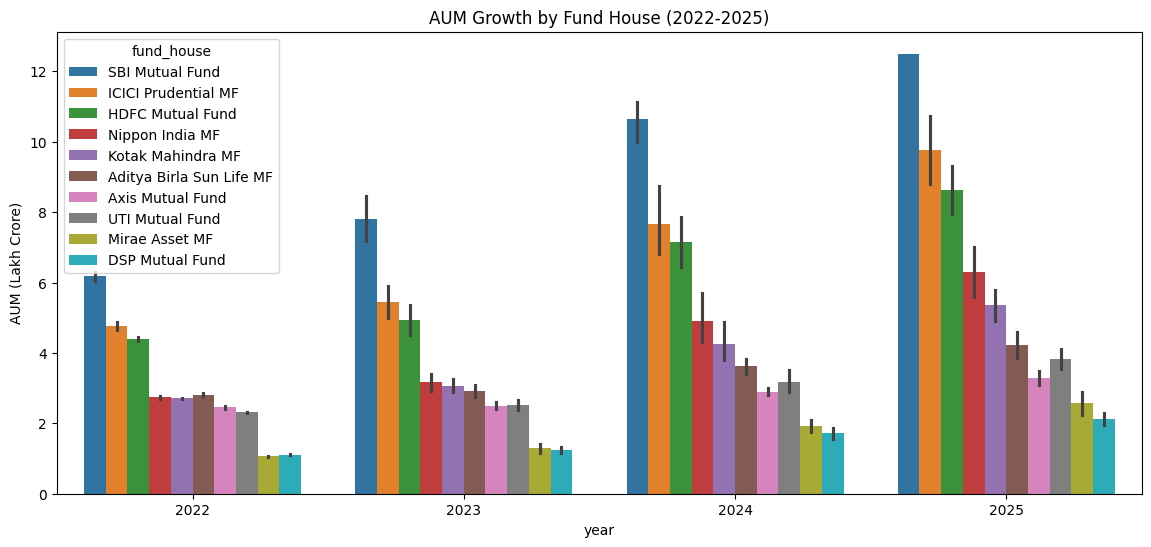

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")

aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.show()

Insight 1:
SBI Mutual Fund consistently maintained the highest AUM among major fund houses, reaching approximately ₹12.5 lakh crore and demonstrating market leadership.

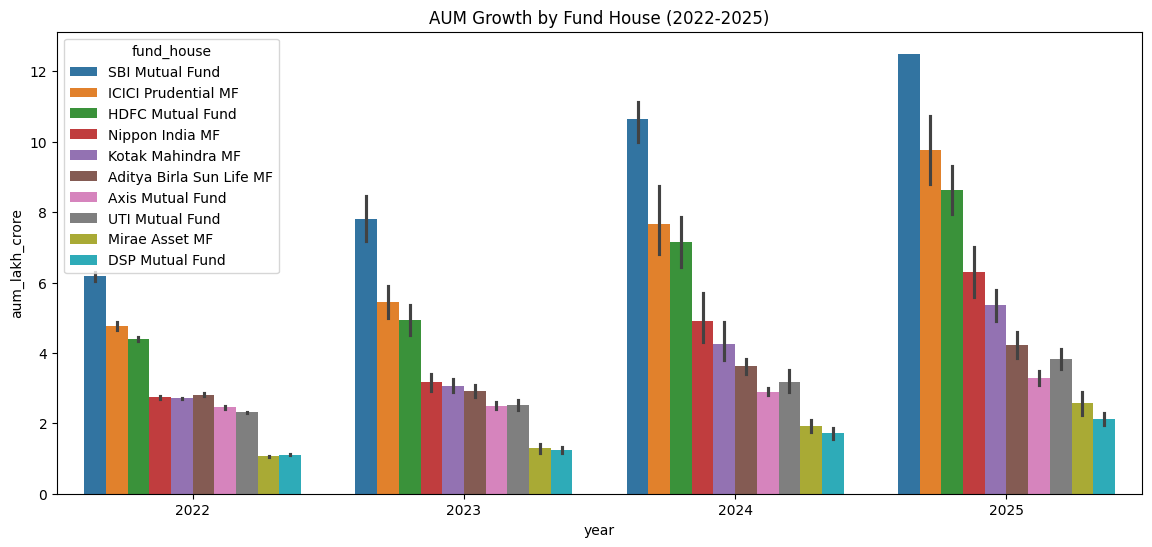

In [12]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")

plt.savefig("AUM_Growth_BarChart.png", bbox_inches="tight")
plt.show()

In [13]:
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")

print(sip.columns.tolist())
print(sip.head())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


In [14]:
import pandas as pd
import plotly.express as px

sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022-2025)"
)

fig.add_annotation(
    x=sip.loc[sip["sip_inflow_crore"].idxmax(), "month"],
    y=sip["sip_inflow_crore"].max(),
    text=f"Peak SIP: ₹{sip['sip_inflow_crore'].max():,.0f} Cr",
    showarrow=True
)

fig.show()

Insight 2:
Monthly SIP inflows showed a strong upward trend from 2022 to 2025, reaching an all-time high at the end of the period, indicating increasing retail investor participation.

In [15]:
fig.write_html("SIP_Trend.html")

In [16]:
category = pd.read_csv("data/raw/05_category_inflows.csv")

print(category.columns.tolist())
print(category.head())

['month', 'category', 'net_inflow_crore']
     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


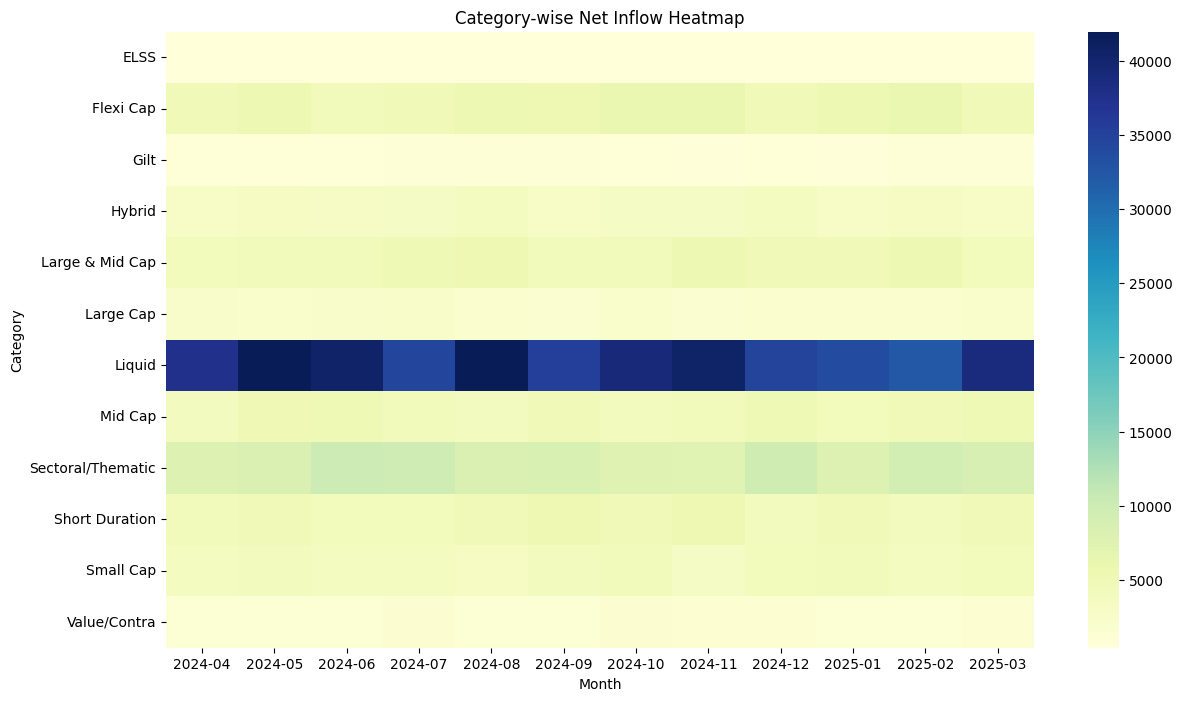

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

category = pd.read_csv("data/raw/05_category_inflows.csv")

pivot_table = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot_table,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

Insight 3:
Flexi Cap, Mid Cap, and Small Cap categories consistently attracted strong inflows, reflecting investor preference for growth-oriented equity funds.

In [18]:
transactions = pd.read_csv("data/raw/08_investor_transactions.csv")

print(transactions.columns.tolist())
print(transactions.head())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female      

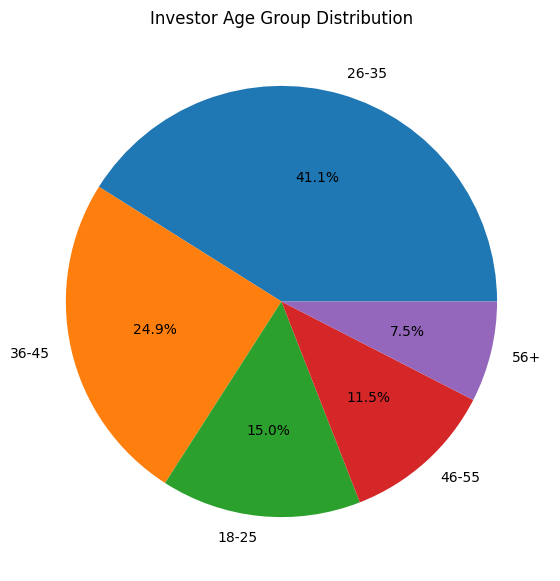

In [19]:
import matplotlib.pyplot as plt

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%")
plt.title("Investor Age Group Distribution")

plt.show()

The majority of investors belong to the 26–45 age group, indicating strong participation from working professionals.

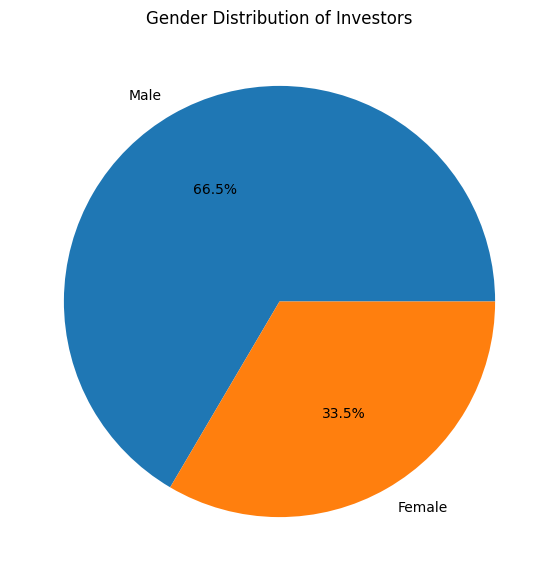

In [20]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%")
plt.title("Gender Distribution of Investors")

plt.show()

Male investors account for a larger share of mutual fund transactions compared to female investors.

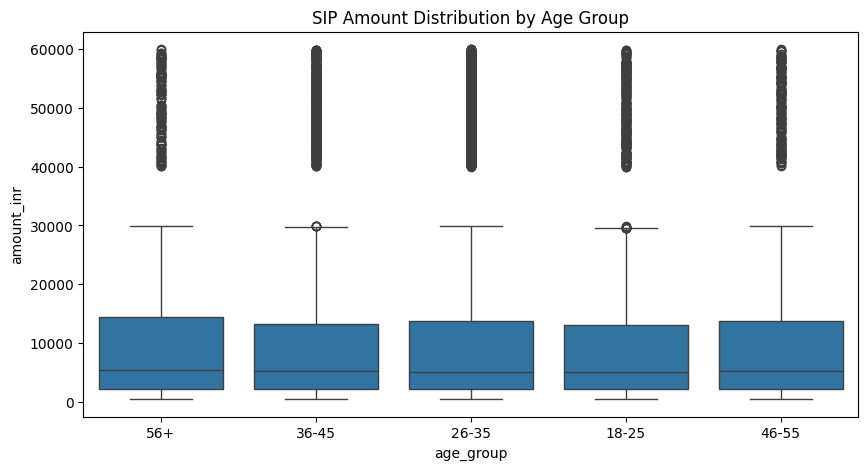

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sip_data = transactions[
    transactions["transaction_type"] == "SIP"
]

plt.figure(figsize=(10,5))

sns.boxplot(
    data=sip_data,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.show()

Middle-aged investors generally contribute larger SIP amounts than younger investors.

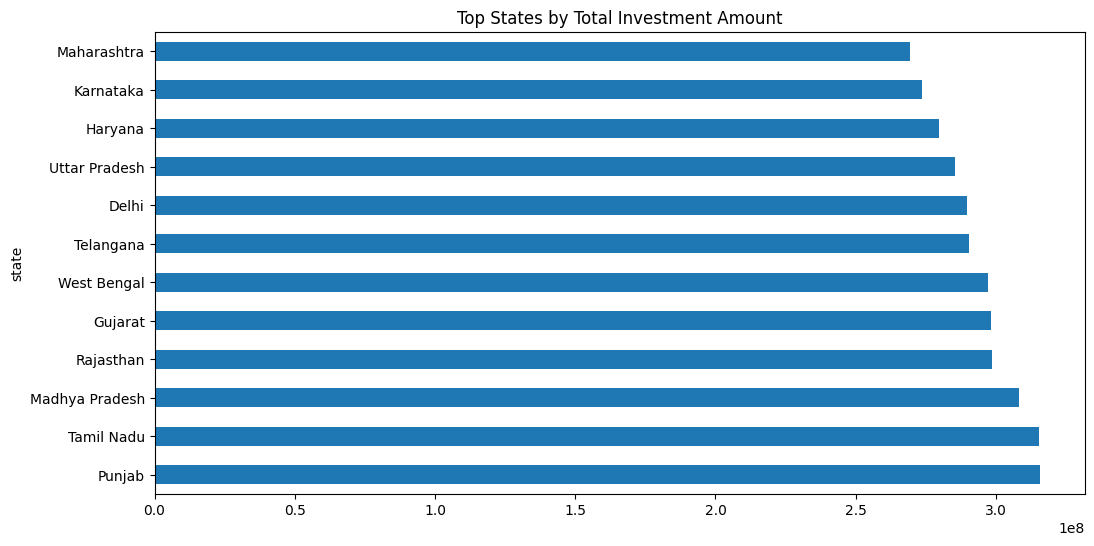

In [22]:
state_data = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

state_data.plot(kind="barh")

plt.title("Top States by Total Investment Amount")

plt.show()

A few large states contribute a significant portion of total mutual fund investments.

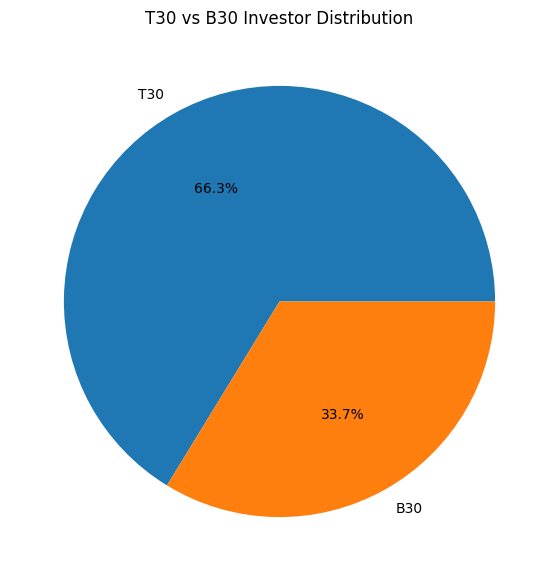

In [23]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

T30 cities contribute the majority of mutual fund activity, though B30 participation continues to grow.

In [24]:
folio = pd.read_csv("data/raw/06_industry_folio_count.csv")

print(folio.columns.tolist())
print(folio.head())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


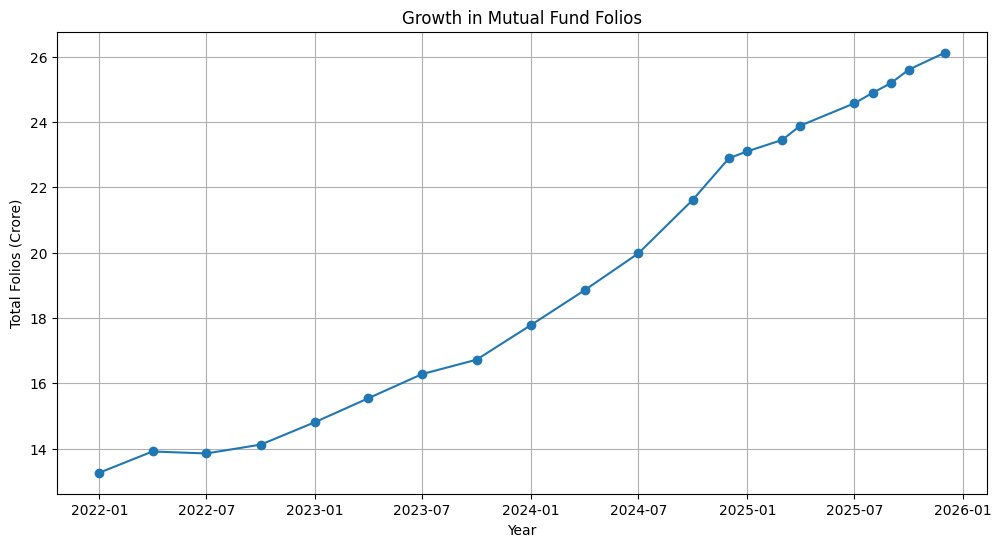

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

folio = pd.read_csv("data/raw/06_industry_folio_count.csv")

folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Growth in Mutual Fund Folios")
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.show()

### Finding 10
Total mutual fund folios increased steadily from approximately 13.26 crore in 2022 to over 26 crore by the end of 2025, reflecting strong retail investor growth.

In [26]:
holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")

print(holdings.columns.tolist())
print(holdings.head())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


In [27]:
performance = pd.read_csv("data/raw/07_scheme_performance.csv")

print(performance.columns.tolist())
print(performance.head())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small 

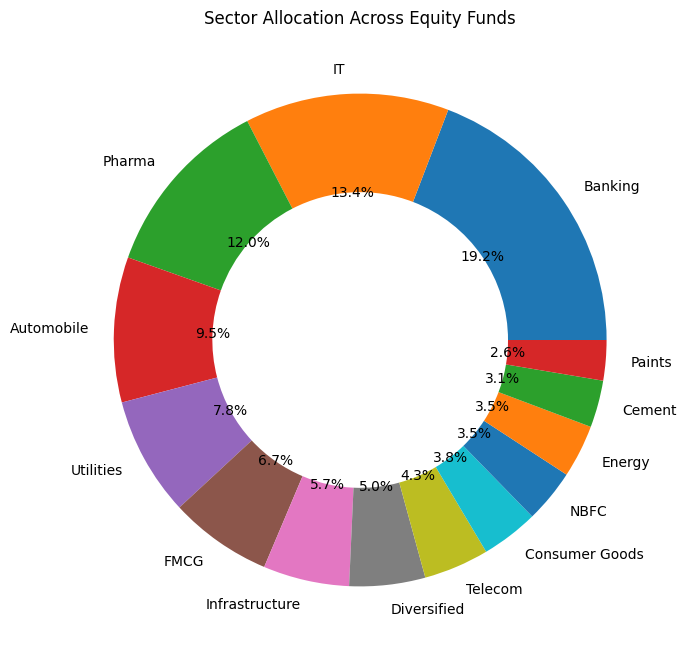

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")

sector_weights = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

### Finding 11
Banking, Pharma, Utilities, and diversified sectors account for a significant share of portfolio allocations across mutual funds.

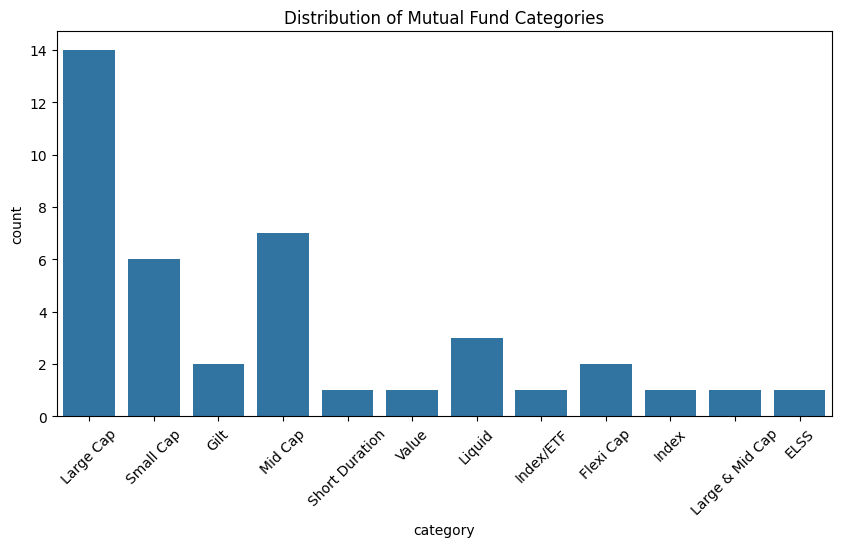

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.countplot(
    data=performance,
    x="category"
)

plt.xticks(rotation=45)

plt.title("Distribution of Mutual Fund Categories")

plt.show()

### Finding 12
Large Cap, Small Cap, and Hybrid categories represent a substantial portion of the mutual fund universe.

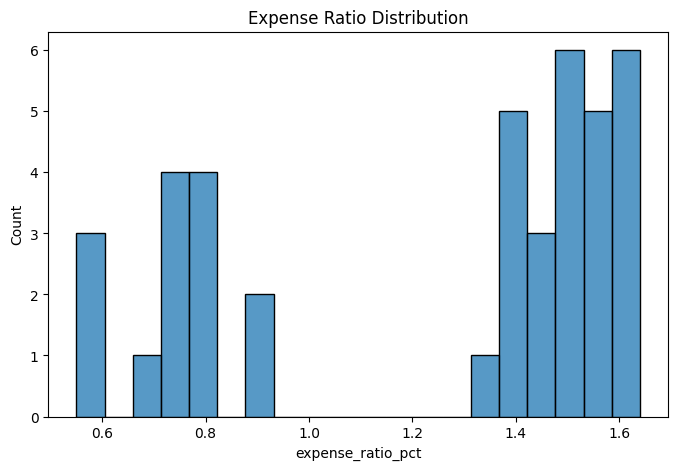

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=20
)

plt.title("Expense Ratio Distribution")

plt.show()

### Finding 13
Most schemes maintain expense ratios within the industry-recommended range of 0.1%–2.5%.

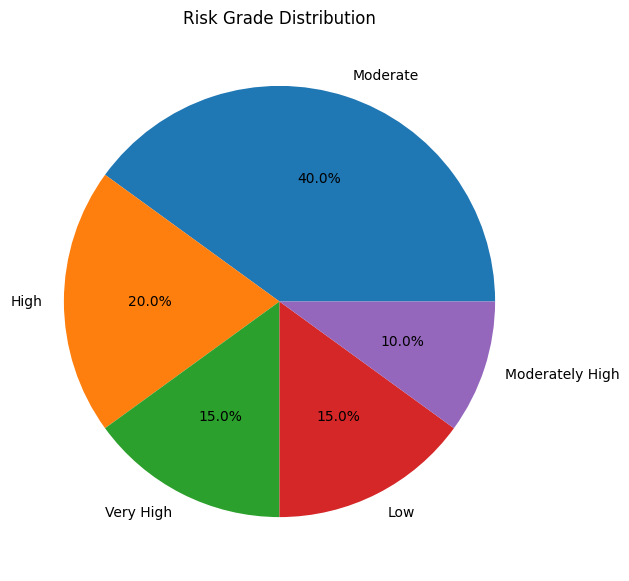

In [31]:
risk_counts = performance["risk_grade"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct="%1.1f%%"
)

plt.title("Risk Grade Distribution")

plt.show()

### Finding 14
Moderate and High-risk funds dominate the market, reflecting investor preference for growth-oriented investments.

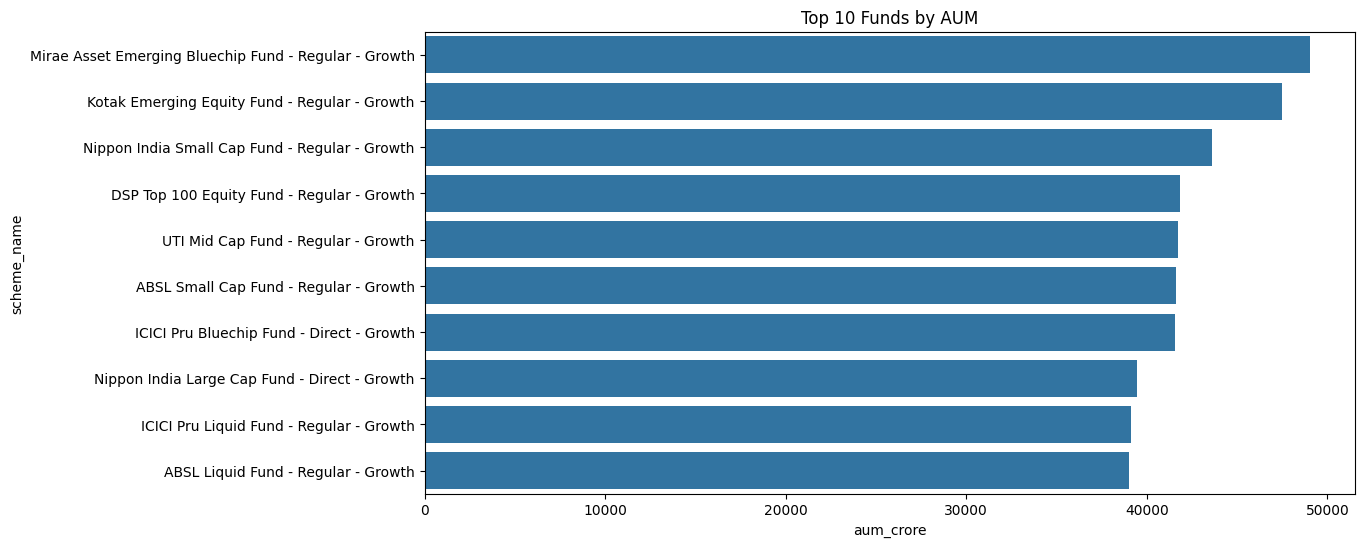

In [32]:
top_aum = (
    performance
    .sort_values("aum_crore", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_aum,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Funds by AUM")

plt.show()

### Finding 15
A small number of schemes account for a disproportionately large share of total assets under management.

In [33]:
print(nav["amfi_code"].nunique())

40


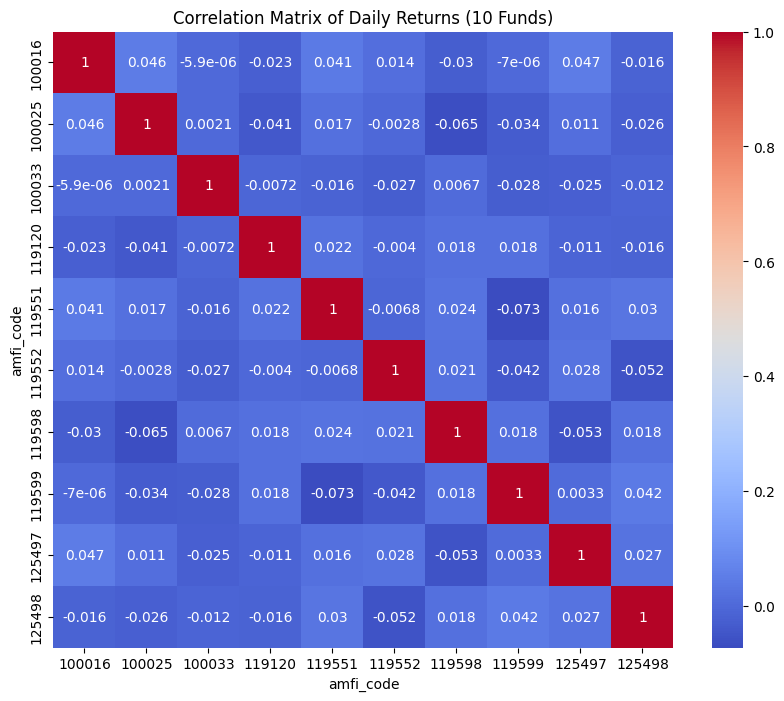

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

nav = pd.read_csv("data/raw/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

# Select 10 funds
selected_funds = nav["amfi_code"].unique()[:10]

nav_10 = nav[
    nav["amfi_code"].isin(selected_funds)
]

# Pivot table
pivot_nav = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Daily returns
returns = pivot_nav.pct_change().dropna()

# Correlation matrix
corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Daily Returns (10 Funds)")

plt.show()

### Finding 16
Most equity-oriented funds exhibit positive correlations in daily returns, indicating exposure to common market movements.

# Conclusion

The EDA revealed strong growth in SIP participation, rising folio counts, concentration of AUM among leading fund houses, and significant investor activity in T30 cities. Equity-oriented categories continued to attract substantial inflows, reflecting positive investor sentiment during the study period.